<a href="https://colab.research.google.com/github/SampathJyotsna-coder/Thiranex/blob/main/project_2_Thiranex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== DATASET ==========
   Age  Income  Experience  Gender  Purchased
0   56   81476          13  Female          0
1   46   64811           2    Male          1
2   32   56208           4  Female          1
3   25   40150           4  Female          0
4   38   91180          18    Male          0

========== DATA PREPROCESSING ==========

Training Data Shape: (400, 4)
Testing Data Shape: (100, 4)

========== DECISION TREE MODEL ==========

Decision Tree Accuracy: 44.0 %

========== RANDOM FOREST MODEL ==========

Random Forest Accuracy: 54.0 %


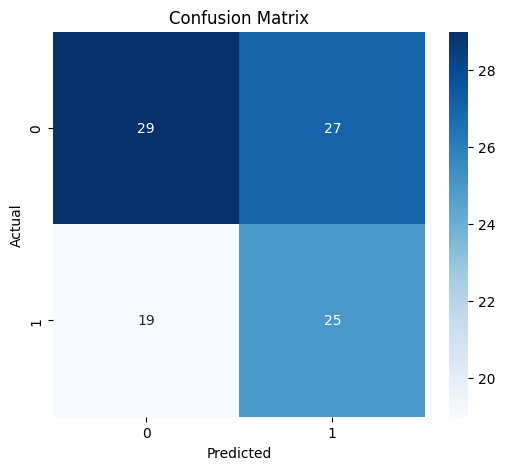


========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.60      0.52      0.56        56
           1       0.48      0.57      0.52        44

    accuracy                           0.54       100
   macro avg       0.54      0.54      0.54       100
weighted avg       0.55      0.54      0.54       100



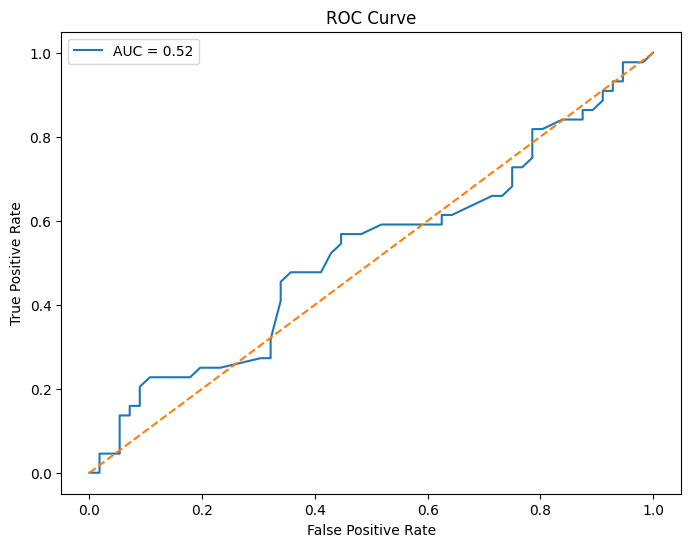

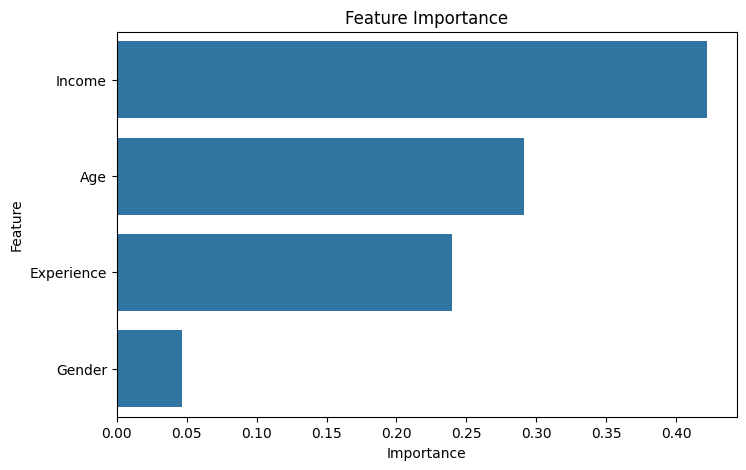


========== FINAL INSIGHTS ==========
Best Performing Model : Random Forest

Project Successfully Completed!
Machine Learning + Prediction + Evaluation Done


In [1]:
# =========================================================
# PREDICTIVE MODELING USING MACHINE LEARNING
# Internship Project - Customer Purchase Prediction
# =========================================================

# ---------------------------------------------------------
# STEP 1 : IMPORT LIBRARIES
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# STEP 2 : CREATE SAMPLE DATASET
# ---------------------------------------------------------

np.random.seed(42)

data = {
    "Age": np.random.randint(18, 60, 500),
    "Income": np.random.randint(20000, 120000, 500),
    "Experience": np.random.randint(0, 20, 500),
    "Gender": np.random.choice(["Male", "Female"], 500),
    "Purchased": np.random.choice([0, 1], 500)
}

df = pd.DataFrame(data)

print("========== DATASET ==========")
print(df.head())

# ---------------------------------------------------------
# STEP 3 : DATA PREPROCESSING
# ---------------------------------------------------------

print("\n========== DATA PREPROCESSING ==========")

# Convert categorical values to numeric
encoder = LabelEncoder()
df["Gender"] = encoder.fit_transform(df["Gender"])

# Features and Target
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

# ---------------------------------------------------------
# STEP 4 : TRAIN TEST SPLIT
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ---------------------------------------------------------
# STEP 5 : DECISION TREE MODEL
# ---------------------------------------------------------

print("\n========== DECISION TREE MODEL ==========")

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predictions
dt_predictions = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("\nDecision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

# ---------------------------------------------------------
# STEP 6 : RANDOM FOREST MODEL
# ---------------------------------------------------------

print("\n========== RANDOM FOREST MODEL ==========")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("\nRandom Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

# ---------------------------------------------------------
# STEP 7 : CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------------------------------------------------
# STEP 8 : CLASSIFICATION REPORT
# ---------------------------------------------------------

print("\n========== CLASSIFICATION REPORT ==========")

print(classification_report(y_test, rf_predictions))

# ---------------------------------------------------------
# STEP 9 : ROC CURVE
# ---------------------------------------------------------

# Probability predictions
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

roc_score = roc_auc_score(y_test, rf_probs)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"AUC = {roc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

# ---------------------------------------------------------
# STEP 10 : FEATURE IMPORTANCE
# ---------------------------------------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.show()

# ---------------------------------------------------------
# STEP 11 : FINAL INSIGHTS
# ---------------------------------------------------------

print("\n========== FINAL INSIGHTS ==========")

best_model = (
    "Random Forest"
    if rf_accuracy > dt_accuracy
    else "Decision Tree"
)

print(f"Best Performing Model : {best_model}")

print("\nProject Successfully Completed!")
print("Machine Learning + Prediction + Evaluation Done")

# =========================================================
# END OF PROJECT
# =========================================================